# **HOW TO USE A PUBLIC API**

In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'10',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0092308a683e405a901549c5a04bfc62 ',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)


#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data

# If that didn't work try using the local host URL as shown in the video

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20029159, 'total_supply': 20029159, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12634, 'cmc_rank': 1, 'last_updated': '2026-05-14T08:04:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1595159506331.08, 'quote': {'USD': {'price': 79641.86146463187, 'volume_24h': 36540713166.22602, 'cex_volume_24h': 36488526391.69329, 'dex_volume_24h': 52186774.53272713, 'volume_change_24h': 19.735, 'percent_change_1h': -0.13429587, 'percent_change_24h': -1.7051444, 'percent_change_7d': -2.31556145, 'percent_change_30d': 6.81880286, 'percent_change_60d': 11.40834482, 'percent_change_90d': 20.10974444, 'market_cap': 1595159506331.0847, 'market_cap_dominance': 60.0947, 'fully_diluted_market_cap': 1672479090757.27, 'tvl': None, 'last_updated': '2026-0

In [2]:
type(data)

dict

In [3]:
import pandas as pd 
pd.set_option('display.max_columns', None)

In [4]:
df= pd.json_normalize(data['data'])
df['timestamp']=pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.002916e+07,2.002916e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12634,1,2026-05-14T08:04:00.000Z,None,NaN,NaN,NaN,1.595160e+12,"[mineable, pow, sha-256, store-of-value, state...",79641.861465,3.654071e+10,3.648853e+10,5.218677e+07,19.7350,-0.134296,-1.705144,-2.315561,6.818803,11.408345,20.109744,1.595160e+12,60.0947,1.672479e+12,None,2026-05-14T08:04:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:06:40.336404
1,1027,Ethereum,ETH,ethereum,True,1.206862e+08,1.206862e+08,NaN,2015-08-07T00:00:00.000Z,11959,2,2026-05-14T08:04:00.000Z,None,NaN,NaN,NaN,2.730877e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2262.792213,1.557147e+10,1.548349e+10,8.797866e+07,7.1991,-0.146386,-1.717746,-3.507111,-4.862062,7.378158,16.777803,2.730877e+11,10.2881,2.730877e+11,None,2026-05-14T08:04:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:06:40.336404
2,825,Tether USDt,USDT,tether,True,1.898575e+11,1.931958e+11,NaN,2015-02-25T00:00:00.000Z,181538,3,2026-05-14T08:04:00.000Z,None,NaN,NaN,NaN,1.930960e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999483,8.065120e+10,7.873382e+10,1.917378e+09,11.4464,-0.012422,-0.009930,-0.024337,-0.084745,-0.067148,0.006280,1.897594e+11,7.1488,1.930960e+11,None,2026-05-14T08:04:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-14 10:06:40.336404
3,1839,BNB,BNB,bnb,False,1.347855e+08,1.347855e+08,1.347855e+08,2017-07-25T00:00:00.000Z,3231,4,2026-05-14T08:04:00.000Z,None,NaN,NaN,NaN,9.021791e+10,"[marketplace, centralized-exchange, payments, ...",669.344372,1.705650e+09,1.659401e+09,4.624939e+07,-6.8431,-0.135442,-1.468938,2.584558,8.938465,1.381054,11.944611,9.021791e+10,3.3988,9.021791e+10,None,2026-05-14T08:04:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:06:40.336404
4,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1833,5,2026-05-14T08:04:00.000Z,None,NaN,NaN,NaN,1.431088e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.431293,2.358133e+09,2.356682e+09,1.451545e+06,3.8825,-0.184040,-2.112351,0.801897,4.602179,1.624108,5.806220,8.844851e+10,3.3321,1.431293e+11,None,2026-05-14T08:04:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:06:40.336404
5,3408,USDC,USDC,usd-coin,False,7.673887e+10,7.673887e+10,NaN,2018-10-08T00:00:00.000Z,39448,6,2026-05-14T08:04:00.000Z,None,NaN,6.090122e+10,6.088887e+10,7.672331e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999797,1.152041e+10,9.217189e+09,2.303224e+09,16.7656,0.006228,0.013374,0.007794,0.009673,-0.007278,-0.050324,7.672331e+10,2.8904,7.672331e+10,None,2026-05-14T08:04:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-14 10:06:40.336404
6,5426,Solana,SOL,solana,True,5.780013e+08,6.263559e+08,NaN,2020-04-10T00:00:00.000Z,1129,7,2026-05-14T08:04:00.000Z,None,NaN,5.252369e+08,4.767334e+10,5.685145e+10,"[pos, platform, solana-ecosystem, cms-holdings...",90.765413,4.738415e+09,4.738399e+09,1.515317e+04,17.9746,-0.591577,-4.651497,0.717414,5.720237,2.887748,15.012105,5.246252e+10,1.9764,5.685145e+10,None,2026-05-14T08:04:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:06:40.336404
7,1958,TRON,TRX,tron,True,9.479928e+10,9.479928e+10,NaN,2017-09-13T00:00:00.000Z,1340,8,2026-05-14T08:05:00.000Z,None,NaN,9.466789e

In [18]:
def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    parameters = {
  'start':'1',
  'limit':'10',
  'convert':'USD'
    }
    headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0092308a683e405a901549c5a04bfc62 ',
    }

    session = Session()
    session.headers.update(headers)

    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)
    
    df2= pd.json_normalize(data['data'])
    df2['timestamp']=pd.to_datetime('now')
    #df = pd.concat([df2, df2], ignore_index=True)
    df 

    if not os.path.isfile(r'/Users/suecortesmachado/Documents/API.csv'):
        df.to_csv(r'/Users/suecortesmachado/Documents/API.csv', header='column_names')
    else: 
         df.to_csv(r'/Users/suecortesmachado/Documents/API.csv', mode='a', header=False)

        
    

In [19]:
import os
from time import time 
from time import sleep 

for i in range(333):
    api_runner()
    print('API Runnner Completed Succesfully')
    sleep(10)#sleep for 1 minute 
exit()

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20029159, 'total_supply': 20029159, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12634, 'cmc_rank': 1, 'last_updated': '2026-05-14T08:31:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1597510730522.54, 'quote': {'USD': {'price': 79759.25152536537, 'volume_24h': 36834290755.35584, 'cex_volume_24h': 36782087912.9784, 'dex_volume_24h': 52202842.37744977, 'volume_change_24h': 18.0964, 'percent_change_1h': -0.0266115, 'percent_change_24h': -1.50455524, 'percent_change_7d': -2.07986737, 'percent_change_30d': 6.77042113, 'percent_change_60d': 11.46332995, 'percent_change_90d': 20.18554708, 'market_cap': 1597510730522.5356, 'market_cap_dominance': 60.1536, 'fully_diluted_market_cap': 1674944282032.67, 'tvl': None, 'last_updated': '2026-0

KeyboardInterrupt: 

In [20]:
df 

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.002916e+07,2.002916e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12634,1,2026-05-14T08:22:00.000Z,None,NaN,NaN,NaN,1.597179e+12,"[mineable, pow, sha-256, store-of-value, state...",79742.709992,3.665327e+10,3.660110e+10,5.216923e+07,19.8331,0.062429,-1.578630,-1.970651,6.948689,11.310022,20.240155,1.597179e+12,60.0885,1.674597e+12,None,2026-05-14T08:22:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:23:49.501410
1,1027,Ethereum,ETH,ethereum,True,1.206862e+08,1.206862e+08,NaN,2015-08-07T00:00:00.000Z,11959,2,2026-05-14T08:22:00.000Z,None,NaN,NaN,NaN,2.734563e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2265.845824,1.597701e+10,1.588876e+10,8.824842e+07,11.4377,0.090385,-1.583178,-3.053267,-4.703108,7.355521,16.784677,2.734563e+11,10.2879,2.734563e+11,None,2026-05-14T08:22:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:23:49.501410
2,825,Tether USDt,USDT,tether,True,1.898575e+11,1.931958e+11,NaN,2015-02-25T00:00:00.000Z,181549,3,2026-05-14T08:22:00.000Z,None,NaN,NaN,NaN,1.930923e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999464,8.129303e+10,7.936154e+10,1.931494e+09,12.8500,-0.008128,-0.003226,-0.035781,-0.082755,-0.055549,0.019732,1.897558e+11,7.1389,1.930923e+11,None,2026-05-14T08:22:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-14 10:23:49.501410
3,1839,BNB,BNB,bnb,False,1.347855e+08,1.347855e+08,1.347855e+08,2017-07-25T00:00:00.000Z,3231,4,2026-05-14T08:21:00.000Z,None,NaN,NaN,NaN,9.035589e+10,"[marketplace, centralized-exchange, payments, ...",670.368109,1.707175e+09,1.660918e+09,4.625681e+07,-6.8844,0.269822,-1.277523,3.177535,8.679804,1.268500,12.071600,9.035589e+10,3.3993,9.035590e+10,None,2026-05-14T08:21:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:23:49.501410
4,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1833,5,2026-05-14T08:22:00.000Z,None,NaN,NaN,NaN,1.433302e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.433507,2.357213e+09,2.355767e+09,1.445907e+06,3.9308,0.171825,-1.921763,1.181706,4.744899,1.506629,5.638289,8.858532e+10,3.3327,1.433507e+11,None,2026-05-14T08:22:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:23:49.501410
5,3408,USDC,USDC,usd-coin,False,7.673887e+10,7.673887e+10,NaN,2018-10-08T00:00:00.000Z,39448,6,2026-05-14T08:21:00.000Z,None,NaN,6.090122e+10,6.088570e+10,7.671932e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999745,1.157097e+10,9.274807e+09,2.296160e+09,17.7688,-0.003185,-0.000127,-0.021192,0.009217,-0.004655,-0.000550,7.671932e+10,2.8863,7.671932e+10,None,2026-05-14T08:21:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-14 10:23:49.501410
6,5426,Solana,SOL,solana,True,5.780013e+08,6.263558e+08,NaN,2020-04-10T00:00:00.000Z,1129,7,2026-05-14T08:22:00.000Z,None,NaN,5.252369e+08,4.779246e+10,5.699350e+10,"[pos, platform, solana-ecosystem, cms-holdings...",90.992207,4.758788e+09,4.758773e+09,1.504038e+04,19.9897,0.238188,-4.400122,1.325017,5.956306,2.917688,15.126893,5.259361e+10,1.9787,5.699350e+10,None,2026-05-14T08:22:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:23:49.501410
7,1958,TRON,TRX,tron,True,9.479928e+10,9.479928e+10,NaN,2017-09-13T00:00:00.000Z,1340,8,2026-05-14T08:22:00.000Z,None,NaN,9.466789e+

In [ ]:
df71=pd.read_csv(r'/Users/suecortesmachado/Documents/API.csv')
df71

In [22]:
pd.set_option('display.float_format', lambda x: '%.5f'% x)

In [23]:
df 


,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20029159.00000,20029159.00000,21000000.00000,2010-07-13T00:00:00.000Z,12634,1,2026-05-14T08:22:00.000Z,None,NaN,NaN,NaN,1597179417510.66992,"[mineable, pow, sha-256, store-of-value, state...",79742.70999,36653266195.59842,36601096961.93477,52169233.66366,19.83310,0.06243,-1.57863,-1.97065,6.94869,11.31002,20.24015,1597179417510.67090,60.08850,1674596909821.53003,None,2026-05-14T08:22:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:23:49.501410
1,1027,Ethereum,ETH,ethereum,True,120686172.97636,120686172.97636,NaN,2015-08-07T00:00:00.000Z,11959,2,2026-05-14T08:22:00.000Z,None,NaN,NaN,NaN,273456261014.67001,"[pos, smart-contracts, ethereum-ecosystem, coi...",2265.84582,15977011308.40916,15888762884.73356,88248423.67559,11.43770,0.09038,-1.58318,-3.05327,-4.70311,7.35552,16.78468,273456261014.66727,10.28790,273456261014.67001,None,2026-05-14T08:22:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:23:49.501410
2,825,Tether USDt,USDT,tether,True,189857486520.22604,193195819162.44940,NaN,2015-02-25T00:00:00.000Z,181549,3,2026-05-14T08:22:00.000Z,None,NaN,NaN,NaN,193092309907.79001,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99946,81293034703.04683,79361540310.62650,1931494392.42027,12.85000,-0.00813,-0.00323,-0.03578,-0.08276,-0.05555,0.01973,189755765856.67291,7.13890,193092309907.79001,None,2026-05-14T08:22:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-14 10:23:49.501410
3,1839,BNB,BNB,bnb,False,134785482.37000,134785482.37000,134785493.60000,2017-07-25T00:00:00.000Z,3231,4,2026-05-14T08:21:00.000Z,None,NaN,NaN,NaN,90355888892.75999,"[marketplace, centralized-exchange, payments, ...",670.36811,1707175150.94508,1660918337.59434,46256813.35074,-6.88440,0.26982,-1.27752,3.17754,8.67980,1.26850,12.07160,90355888892.76057,3.39930,90355896420.99001,None,2026-05-14T08:21:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:23:49.501410
4,52,XRP,XRP,xrp,False,61796225236.00000,99985670046.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1833,5,2026-05-14T08:22:00.000Z,None,NaN,NaN,NaN,143330158152.26001,"[medium-of-exchange, enterprise-solutions, xrp...",1.43351,2357212516.40622,2355766609.21738,1445907.18884,3.93080,0.17183,-1.92176,1.18171,4.74490,1.50663,5.63829,88585321598.72153,3.33270,143350700241.66000,None,2026-05-14T08:22:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-14 10:23:49.501410
5,3408,USDC,USDC,usd-coin,False,76738872056.91780,76738872056.91780,NaN,2018-10-08T00:00:00.000Z,39448,6,2026-05-14T08:21:00.000Z,None,NaN,60901219650.23000,60885703627.09497,76719321018.02000,"[medium-of-exchange, stablecoin, asset-backed-...",0.99975,11570967138.36524,9274806892.04803,2296160246.31722,17.76880,-0.00318,-0.00013,-0.02119,0.00922,-0.00466,-0.00055,76719321018.02187,2.88630,76719321018.02000,None,2026-05-14T08:21:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-14 10:23:49.501410
6,5426,Solana,SOL,solana,True,578001250.99461,626355838.55015,NaN,2020-04-10T00:00:00.000Z,1129,7,2026-05-14T08:22:00.000Z,None,NaN,525236893.30000,47792464105.69550,56993500100.92000,"[pos, platform, solana-ecosystem, cms-holdings...",90.99221,4758787871.46568,4758772831.08866,15040.37702,19.98970,0.23819,-4.40012,1.32502,5.95631,2.91769,15.12689,5

In [24]:
df3=df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.volume_24h', 'quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.volume_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.06243,36653266195.59842,-1.97065,6.94869,11.31002,20.24015
Ethereum,0.09038,15977011308.40916,-3.05327,-4.70311,7.35552,16.78468
Tether USDt,-0.00813,81293034703.04683,-0.03578,-0.08276,-0.05555,0.01973
BNB,0.26982,1707175150.94508,3.17754,8.67980,1.26850,12.07160
XRP,0.17183,2357212516.40622,1.18171,4.74490,1.50663,5.63829
USDC,-0.00318,11570967138.36524,-0.02119,0.00922,-0.00466,-0.00055
Solana,0.23819,4758787871.46568,1.32502,5.95631,2.91769,15.12689
TRON,0.05546,660965058.14820,1.85080,9.23009,18.37676,26.30547
Dogecoin,-0.84377,2201056958.79901,1.65445,21.00167,17.64726,21.54431


In [25]:
df4= df3.stack()
df4

name                                     
Bitcoin      quote.USD.percent_change_1h              0.06243
             quote.USD.volume_24h           36653266195.59842
             quote.USD.percent_change_7d             -1.97065
             quote.USD.percent_change_30d             6.94869
             quote.USD.percent_change_60d            11.31002
             quote.USD.percent_change_90d            20.24015
Ethereum     quote.USD.percent_change_1h              0.09038
             quote.USD.volume_24h           15977011308.40916
             quote.USD.percent_change_7d             -3.05327
             quote.USD.percent_change_30d            -4.70311
             quote.USD.percent_change_60d             7.35552
             quote.USD.percent_change_90d            16.78468
Tether USDt  quote.USD.percent_change_1h             -0.00813
             quote.USD.volume_24h           81293034703.04683
             quote.USD.percent_change_7d             -0.03578
             quote.USD.perce

In [26]:
type(df4)

pandas.core.series.Series

In [28]:
df5=df4.to_frame(name='values')
df5

values
name                                                      
Bitcoin     quote.USD.percent_change_1h            0.06243
            quote.USD.volume_24h         36653266195.59842
            quote.USD.percent_change_7d           -1.97065
            quote.USD.percent_change_30d           6.94869
            quote.USD.percent_change_60d          11.31002
            quote.USD.percent_change_90d          20.24015
Ethereum    quote.USD.percent_change_1h            0.09038
            quote.USD.volume_24h         15977011308.40916
            quote.USD.percent_change_7d           -3.05327
            quote.USD.percent_change_30d          -4.70311
            quote.USD.percent_change_60d           7.35552
            quote.USD.percent_change_90d          16.78468
Tether USDt quote.USD.percent_change_1h           -0.00813
            quote.USD.volume_24h         81293034703.04683
            quote.USD.percent_change_7d           -0.03578
            quote.USD.percent_change_30d          -0.08276
            quote.USD.percent_change_60d          -0.05555
            quote.USD.percent_change_90d           0.01973
BNB         quote.USD.percent_change_1h            0.26982
            quote.USD.volume_24h          1707175150.94508
            quote.USD.percent_change_7d            3.17754
            quote.USD.percent_change_30d           8.67980
            quote.USD.percent_change_60d           1.26850
            quote.USD.percent_change_90d          12.07160
XRP         quote.USD.percent_change_1h            0.17183
            quote.USD.volume_24h          2357212516.40622
            quote.USD.percent_change_7d            1.18171
            quote.USD.percent_change_30d           4.74490
            quote.USD.percent_change_60d           1.50663
            quote.USD.percent_change_90d           5.63829
USDC        quote.USD.percent_change_1h           -0.00318
            quote.USD.volume_24h         11570967138.36524
            quote.USD.percent_change_7d           -0.02119
            quote.USD.percent_change_30d           0.00922
            quote.USD.percent_change_60d          -0.00466
            quote.USD.percent_change_90d          -0.00055
Solana      quote.USD.percent_change_1h            0.23819
            quote.USD.volume_24h          4758787871.46568
            quote.USD.percent_change_7d            1.32502
            quote.USD.percent_change_30d           5.95631
            quote.USD.percent_change_60d           2.91769
            quote.USD.percent_change_90d          15.12689
TRON        quote.USD.percent_change_1h            0.05546
            quote.USD.volume_24h           660965058.14820
            quote.USD.percent_change_7d            1.85080
            quote.USD.percent_change_30d           9.23009
            quote.USD.percent_change_60d          18.37676
            quote.USD.percent_change_90d          26.30547
Dogecoin    quote.USD.percent_change_1h           -0.84377
            quote.USD.volume_24h          2201056958.79901
            quote.USD.percent_change_7d            1.65445
            quote.USD.percent_change_30d          21.00167
            quote.USD.percent_change_60d          17.64726
            quote.USD.percent_change_90d          21.54431
Hyperliquid quote.USD.percent_change_1h           -0.06267
            quote.USD.volume_24h           287373928.11106
            quote.USD.percent_change_7d           -9.58277
            quote.USD.percent_change_30d         -13.11174
            quote.USD.percent_change_60d           4.48409
            quote.USD.percent_change_90d          27.20279

In [30]:
df5.count()

values    60
dtype: int64

In [38]:
index= pd.Index(range(60))

df6=df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.06243
1,Bitcoin,quote.USD.volume_24h,36653266195.59842
2,Bitcoin,quote.USD.percent_change_7d,-1.97065
3,Bitcoin,quote.USD.percent_change_30d,6.94869
4,Bitcoin,quote.USD.percent_change_60d,11.31002
5,Bitcoin,quote.USD.percent_change_90d,20.24015
6,Ethereum,quote.USD.percent_change_1h,0.09038
7,Ethereum,quote.USD.volume_24h,15977011308.40916
8,Ethereum,quote.USD.percent_change_7d,-3.05327
9,Ethereum,quote.USD.percent_change_30d,-4.70311


In [51]:
df6.rename(columns={'level_1':'percent_change'},inplace = True)
df6

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,0.06243
1,Bitcoin,quote.USD.volume_24h,36653266195.59842
2,Bitcoin,quote.USD.percent_change_7d,-1.97065
3,Bitcoin,quote.USD.percent_change_30d,6.94869
4,Bitcoin,quote.USD.percent_change_60d,11.31002
5,Bitcoin,quote.USD.percent_change_90d,20.24015
6,Ethereum,quote.USD.percent_change_1h,0.09038
7,Ethereum,quote.USD.volume_24h,15977011308.40916
8,Ethereum,quote.USD.percent_change_7d,-3.05327
9,Ethereum,quote.USD.percent_change_30d,-4.70311


In [52]:
import seaborn as sns 
import matplotlib.pyplot as plt 

In [57]:
df6['percent_change']= df6['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.volume_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df6

,name,percent_change,values
0,Bitcoin,1h,0.06243
1,Bitcoin,24h,36653266195.59842
2,Bitcoin,7d,-1.97065
3,Bitcoin,30d,6.94869
4,Bitcoin,60d,11.31002
5,Bitcoin,90d,20.24015
6,Ethereum,1h,0.09038
7,Ethereum,24h,15977011308.40916
8,Ethereum,7d,-3.05327
9,Ethereum,30d,-4.70311


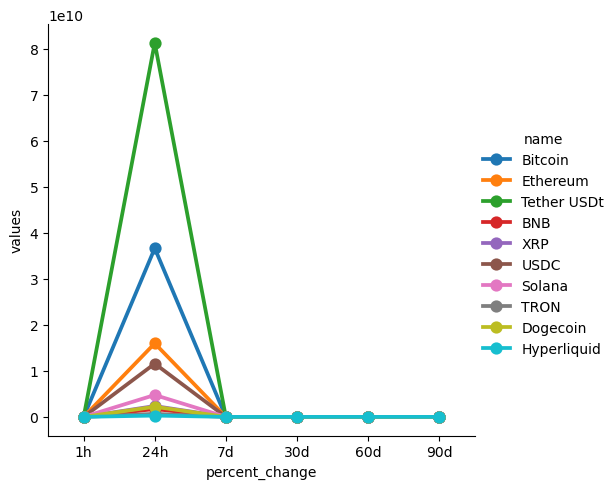

In [58]:
sns.catplot(x='percent_change',y='values', hu e='name', data=df6, kind='point')

In [81]:
df7=df[['name','quote.USD.price','timestamp']]
df=df7.query("name=='Bitcoin'")
df7 

,name,quote.USD.price,timestamp
0,Bitcoin,79742.70999,2026-05-14 10:23:49.501410
10,Bitcoin,79742.70999,2026-05-14 10:23:49.501410


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

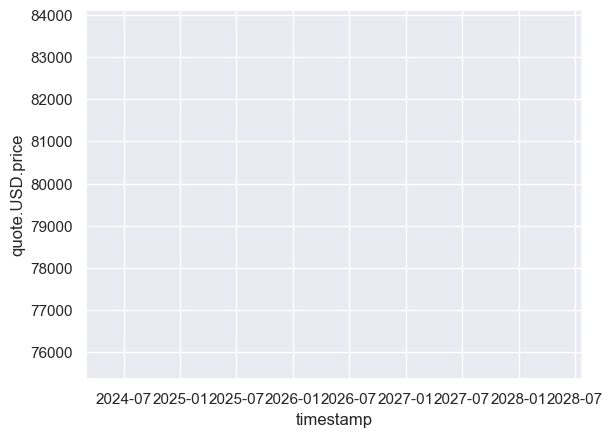

In [82]:
sns.set_theme(style='darkgrid')
sns.lineplot(x='timestamp',y='quote.USD.price',data=df7)